# Python Refresher: Root Finding with fsolve

## Why Are We Learning This?
Many reactor design problems require solving nonlinear systems of equations that cannot be rearranged analytically. Key examples are non-isothermal CSTR design problems and CSTR design problems that involve multiple reactions. This notebook is a refresher of the scipy.optimize.fsolve function, which can be used for solving CSTR design equations.

## Learning Objectives
- Use fsolve to determine roots
- Understand the role of the initial guess
- Visualize non-isothermal CSTR solutions graphically


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

## Example 1: A Simple Nonlinear Equation
Solve:

$$x^2 - 4 = 0$$

In [ ]:
def equation(x):
    return x**2 - 4

solution = fsolve(equation, x0=1)
print("Root near x=1:", solution)

Root near x=1: [2.]


In [ ]:
solution = fsolve(equation, x0=-1)
print("Root near x=-1:", solution)

Root near x=-1: [-2.]


### Key Lesson
The root returned by fsolve can depend on the initial guess.

## Example 2: Reactor Design Interpretation
For a non-isothermal CSTR, the steady-state temperature is found where the mole balance and energy balance curves intersect. This can be written as:

$$X_{MB}(T) - X_{EB}(T) = 0$$

which is exactly the form needed by fsolve.

To illustrate how fsolve can be used in non-isothermal CSTR design problems, consider the problem statement that we covered in class.

## E04 CSTR Energy Balance Example

The elementary liquid phase reaction

$$A \longrightarrow B$$

is carried out in a non-isothermal CSTR. Species A and an inert I are fed to the reactor in equimolar amounts. The molar feed rate of A is 80 mol/min. The heat capacity of the inert is 30 cal/mol/K. The heat capacities of A and B are 20 cal/mol/K. Additionally:

$$\tau = 100 \ \mathrm{min}$$
$$\Delta H^{rxn} = -7500 \ \mathrm{cal/mol} $$
$$UA = 8000 \ \mathrm{cal/min/K}$$
$$T_a = 300 \ \mathrm{K}$$
$$k = 0.0066 \ \mathrm{min}^{-1} \ \mathrm{at} \ 350 \ \mathrm{K}$$
$$ E = 40 \ \mathrm{kcal/mol}$$

Determine the reactor temperature for a feed temperature of 450 K.

In class, we developed the following equations:

$$X_{MB} = \frac{\tau k}{1+\tau k}$$

$$X_{EB} = \frac{F_{A0}C_{P,A}\left(T_0-T\right)+F_{I0}C_{P,I}\left(T_0-T\right) + UA\left(T_a-T\right)}{\Delta H^{rxn} F_{A0}}$$

Let's load the mole (MB) and energy (EB) balances into functions:

In [ ]:
FA0 = 80
FI0 = FA0
CPA = 20
CPI = 30
tau = 100
dHrxn = -7500
UA = 8000
Ta = 300
kref = 0.0066
Tref = 350
T0 = 450
E = 4000
R = 1.987

def k(T):
  return kref*np.exp((E/R)*(1/Tref-1/T))

def XMB(T):
  return tau*k(T)/(1 + tau*k(T))

def XEB(T):
  numerator = FA0*CPA*(T0-T) + FI0*CPI*(T0-T) + UA*(Ta-T)
  denominator = dHrxn*FA0
  return numerator/denominator

def objective(T):
  return XMB(T) - XEB(T)

Now that we've gotten our functions loaded, I like to plot the solutions so that I can see approximately where XMB and XEB intersect. The plot below shows that happens ~375 K:

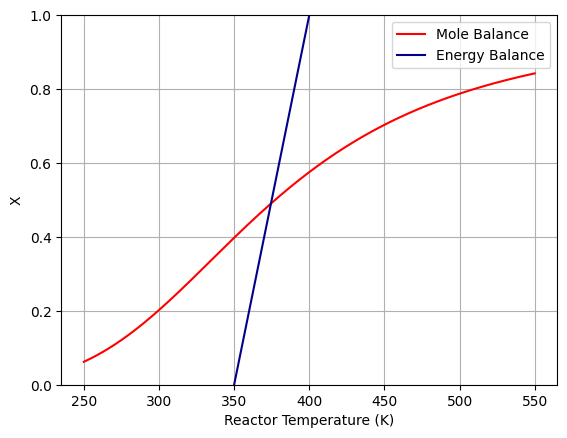

In [ ]:
T = np.linspace(250,550,500)

plt.plot(T, XMB(T), color="red", label="Mole Balance")
plt.plot(T, XEB(T), color="darkblue", label="Energy Balance")
plt.xlabel("Reactor Temperature (K)")
plt.ylabel("X")
plt.legend()
plt.ylim(0, 1)
plt.grid()
plt.show()

In [ ]:
Tguess = 375
T_solution = fsolve(objective, x0=Tguess)
print("Steady-state temperature for a guess of ",Tguess," = ", T_solution[0], " K")

Steady-state temperature for a guess of  375  =  374.51168531825505  K


## Common Student Errors
1. Defining an equation as a variable instead of a function.
2. Forgetting to provide an initial guess.
3. Trusting the solver without checking that f(x)≈0.
4. Using an initial guess far from the desired root, usually due to forgetting to plot the solution first.

## Relevant CBE 3610 Reference Book Equations
- Eq. (21): CSTR Mole Balance
- Eq. (28): CSTR Energy Balance
- Eq. (29): κ Definition
- Eq. (30): Tc Definition
- Eq. (31): Simplified CSTR Energy Balance
- Eq. (44): General Rate Law
- Eq. (45): Power Law Kinetics
- Eq. (49): Arrhenius Equation